# Heart Disease Classification — Modeling & Evaluation

## Objectives
In this notebook I train and evaluate two classification models on the processed data from `02_feature_engineering.ipynb`: Logistic Regression as a baseline and Random Forest for capturing non-linear relationships. 

Logistic Regression is used as the baseline because it is interpretable and handles linear relationships between features and target well. If a simple linear model performs well, there is no need for added complexity. Random Forest is used to capture complex non-linear feature interactions that logistic regression cannot model — such as the `thalach`-`age` interaction identified in EDA.

Both models are evaluated and compared using the same set of metrics to determine which performs better and whether the added complexity of Random Forest is justified.

## Output
Trained logistic regression and random forest models evaluated on accuracy, precision, recall, F1, and AUC-ROC. A confusion matrix and classification report are produced for each model, and a final comparison table and ROC curve to summarize performance across both models.

## 3.1 Setup & Imports

Importing the same core libraries as `01_eda.ipynb` with the addition of `sklearn` modules for modeling and evaluation. Path constants point to the processed data files from `02_feature_engineering.ipynb`. Random state is defined here to ensure reproducibility across all models.

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore') # suppress outputs of warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay

sns.set_theme()
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
X_TRAIN_PATH = '../data/processed/X_train.csv'
X_TEST_PATH = '../data/processed/X_test.csv'
Y_TRAIN_PATH = '../data/processed/y_train.csv'
Y_TEST_PATH = '../data/processed/y_test.csv'

## 3.2 Load Processed Data

Loading the four processed datasets saved from `02_feature_engineering.ipynb` using the path constants defined in 3.1. `.squeeze()` is applied to `y_train` and `y_test` to convert them from single-column DataFrames to 1D Series, which is the format `sklearn` models expect for target variables.

In [2]:
X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_test = pd.read_csv(Y_TEST_PATH).squeeze()


In [4]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


Shapes confirm the data loaded correctly. `X_train` has 242 rows and 13 features, `X_test` has 61 rows and 13 features, consistent with the 80/20 split from `02_feature_engineering.ipynb`. `y_train` and `y_test` are 1D arrays of 242 and 61 values respectively, confirming `.squeeze()` worked correctly.

## 3.3 Baseline Model — Logistic Regression

As the baseline model I implement Logistic Regression using `sklearn`'s `LogisticRegression`. Logistic regression is appropriate here because it models the 
linear relationship between features and the log-odds of the target, is highly interpretable, and serves as a strong baseline before introducing more complex models. The model is fit on `X_train` and `y_train`, then used to generate both class predictions (`predict`) and probability scores (`predict_proba`) for AUC-ROC evaluation.

In [6]:
# create 
lr = LogisticRegression(random_state= RANDOM_STATE)
# fit
lr.fit(X_train, y_train)
# predict
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1] # for AUC-ROC evaluation

To evaluate performance I report precision, recall, F1-score, accuracy, and AUC-ROC. Since this is a medical classification problem, recall on class `1` is the most important metric — it measures how many actual disease cases the model correctly identified.

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

AUC-ROC score: 0.9234913793103449


Text(95.72222222222221, 0.5, 'Actual')

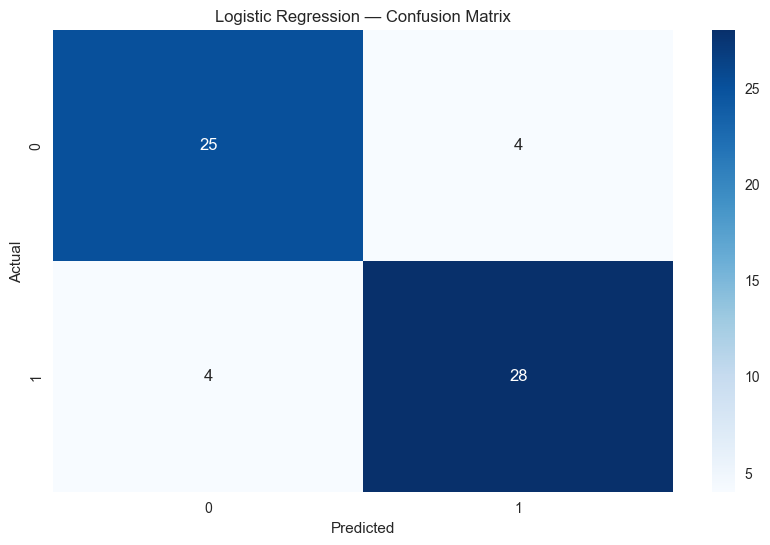

In [7]:
# evaluation
print(classification_report(y_test, y_pred_lr))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot = True, fmt = 'd', cmap= 'Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

The logistic regression baseline performs well. Precision, recall, and F1-score are consistent across both classes at 86-88%, with an overall accuracy of 87%. For a baseline model on a dataset of only 303 patients this is a strong result.

Recall for class `1` (disease present) is 0.88, meaning the model correctly identified 88% of actual disease cases and missed 4/32. While strong for a baseline, recall below 95% in a real clinical deployment would require threshold tuning to reduce false negatives — cases where a patient with disease is predicted as healthy, which in this context is the most costly error.

The AUC-ROC of 0.923 indicates excellent discriminating ability — there is a 92.3% chance the model ranks a random disease patient as higher risk than a random healthy patient.

Macro and weighted averages are both 0.87, consistent with the per-class metrics and reflect the roughly balanced class distribution of 29 no-disease and 32 disease cases in the test set.

The confusion matrix confirms 25 true negatives `(0,0)`, 4 false positives `(0,1)`, 4 false negatives `(1,0)`, and 28 true positives `(1,1)`. False negatives and false positives are equal at 4 each, but false negatives are the greater clinical concern, since misdiagnosing a patient as healthy when they have heart disease is potentially fatal. Future work would include threshold tuning to optimize recall for clinical deployment and error analysis on the 4 missed disease cases to identify any patterns in their feature values.

## 3.4 Random Forest

In addition to logistic regression, I implement Random Forest to capture non-linear relationships between features that logistic regression may have missed — such as the `thalach`-`age` interaction identified in EDA. The model is initialized with `n_estimators=100` — 100 trees balances performance and computational efficiency and is a standard starting point before hyperparameter tuning. `random_state=RANDOM_STATE` ensures reproducibility. Future work would include tuning `n_estimators` and `max_depth` to potentially improve performance.

In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

Same evaluation metrics as `3.3 Baseline Model — Logistic Regression` — precision, recall, F1-score, accuracy, and AUC-ROC — with recall on class `1` remaining the priority metric for this medical classification problem.

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

AUC-ROC score: 0.9391163793103448


Text(95.72222222222221, 0.5, 'Actual')

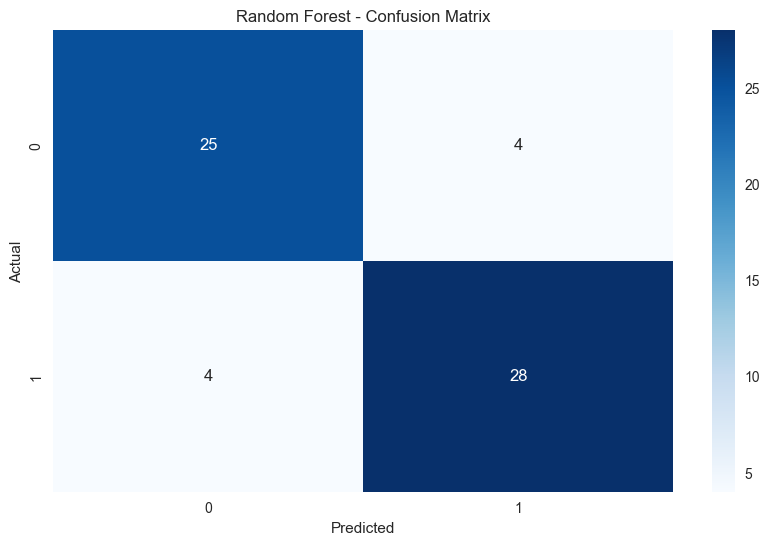

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_rf))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot = True, fmt = 'd', cmap= 'Blues')
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

Random forest produces identical classification metrics to logistic regression — 87% accuracy, 0.88 recall, 0.86-0.88 precision and F1 across both classes. The confusion matrix is also identical: 25 true negatives `(0,0)`, 4 false positives `(0,1)`, 4 false negatives `(1,0)`, and 28 true positives `(1,1)`.

The key difference between the models is the AUC-ROC — 0.939 vs 0.923 for logistic regression. Despite identical hard predictions, random forest assigns more confident probability scores to correct predictions, suggesting it is picking up some non-linear signal not captured by logistic regression. However, the identical confusion matrices suggest that the relationships in this dataset are largely linear and logistic regression accounts for most of the discriminating signal. Hyperparameter tuning may reveal further improvements in random forest performance.

## 3.5 Model Comparison

To compare the models I visualize performance using: a metrics summary table for exact scores side by side, a bar chart for visual comparison across metrics, and an ROC curve to show discriminating ability across all classification thresholds — not just at the default 0.5 cutoff.

To compare both models I first build a summary table showing all metrics side by side, rounded to 4 decimal places for readability.

In [12]:
results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC'],
    'Logistic Regression': [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_pred_proba_lr)],
    'Random Forest': [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_pred_proba_rf)]
}

df = pd.DataFrame(results).round(4)
df.style.hide(axis='index')

Metric,Logistic Regression,Random Forest
Accuracy,0.868900,0.868900
Precision,0.875000,0.875000
Recall,0.875000,0.875000
F1,0.875000,0.875000
AUC-ROC,0.923500,0.939100


The table shows all metrics are equal across both models except AUC-ROC — random forest scores 0.9391 vs 0.9235 for logistic regression. This suggests random forest has slightly better probability calibration and may be capturing some non-linear signal not picked up by logistic regression, despite producing identical hard predictions.

This visual shows the same comparison as in the table visualized as a grouped bar chart — the AUC-ROC difference is visible while all other metrics are equal.

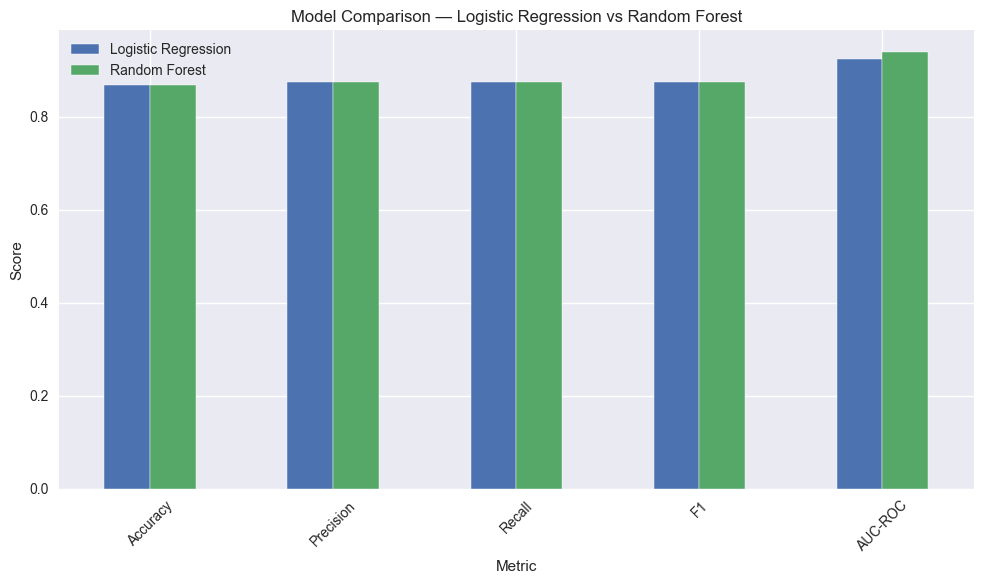

In [13]:
df.set_index('Metric').plot(kind='bar')
plt.title('Model Comparison — Logistic Regression vs Random Forest')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/model_comparison_bar.png', bbox_inches='tight')
plt.show()

To better visualize discriminating ability across all thresholds I plot the ROC curve for both models on the same axes.

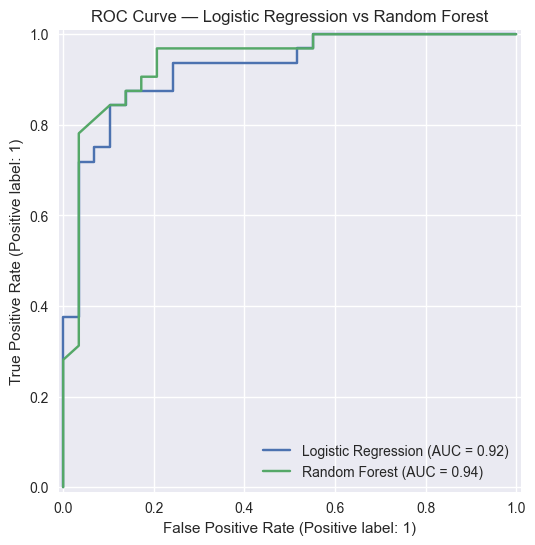

In [14]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_pred_proba_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf, name='Random Forest', ax=ax)
plt.title('ROC Curve — Logistic Regression vs Random Forest')
plt.savefig('../images/roc_curve.png', bbox_inches='tight')
plt.show()

Both curves hug the top left corner closely — this is the ideal region where true positive rate is high and false positive rate is low simultaneously. The curves overlap almost entirely at both ends but random forest sits slightly higher in the middle range, which is consistent with its higher AUC-ROC of 0.94 vs 0.92.

Given the identical classification metrics and confusion matrices, logistic regression is the recommended model for this dataset because it is simpler, more interpretable, and performs equivalently to random forest on hard predictions. Random forest's higher AUC-ROC suggests it may outperform with hyperparameter tuning, which I have identified as the primary next step for future improvement. Additional improvements would include threshold tuning to optimize recall for clinical deployment and testing on a larger dataset to validate these results.

## 3.6 Conclusion

In this notebook I trained and evaluated two classification models — logistic regression as the baseline for its interpretability and ability to model linear relationships, and random forest to capture potential non-linear relationships between features.

Both models performed equally well across all hard classification metrics — 87% accuracy, 0.88 precision, recall, and F1-score — which is a strong result given the small sample size of 303 patients and no hyperparameter tuning. While promising, these metrics would need to be significantly higher for real clinical deployment — particularly recall, which would need to approach 95%+ to minimize the risk of missed diagnoses. The only meaningful difference between the models performance was AUC-ROC, where random forest scored 0.939 vs 0.923 for logistic regression, suggesting random forest is more confident in its probability estimates and may be capturing some non-linear signal.


I reported multiple metrics rather than accuracy alone to ensure a complete picture of model performance was captured — particularly important in medical classification where false negatives are more costly than false positives given their potantial for fatality.

The recommended model for this dataset is logistic regression — it performs equivalently to random forest on all hard metrics, is simpler, and is more interpretable. In a medical context being able to explain model decisions is important, and logistic regression coefficients provide direct insight into feature influence.

Future improvements include hyperparameter tuning for both models, increasing `n_estimators` and tuning `max_depth` for random forest, threshold tuning to optimize recall for clinical deployment, and validating on a larger dataset to confirm these results generalize beyond 303 patients.